In [1]:
import numpy as np
import mdtraj as md

import matplotlib.pyplot as plt
import matplotlib as mpl

import sys
sys.path.insert(0, '/home/rzhu/Desktop/projects/kinase_analysis/src/')
from funcs_db_assign import assign_ramachandran_codes
from funcs_featurise import dbdihed_featuriser

from pathlib import Path
from natsort import natsorted

plt.rcParams['svg.fonttype'] = 'none'

### ABL
---

In [2]:
def get_abl_features(traj):
    psi_indices, psi_angles = md.compute_psi(traj)
    phi_indices, phi_angles = md.compute_phi(traj)

    psi_asp381 = psi_angles[:,np.where(psi_indices==[1091, 1092, 1093, 1099])[0][0]]/np.pi*180 # DFG
    dist_his246_gly250 = md.compute_distances(traj, [[4, 35]],) # g-loop
    dist_tyr253_met388 = md.compute_distances(traj, [[52, 1148]],) # a-loop
    dist_asp276_met278 = md.compute_distances(traj, [[242, 257]],) # c-helix (?)

    # phi_gly249 = phi_angles[:,np.where(phi_indices==[24, 30, 31, 32])[0][0]] # g-loop
    # phi_gly250 = phi_angles[:,np.where(phi_indices==[32, 34, 35, 36])[0][0]] # g-loop
    
    # dist_gly254_val270 = md.compute_distances(traj, [[64, 193]],) # g-loop
    # dist_his246_lys274 = md.compute_distances(traj, [[4, 224]],) # g-loop?

    features = np.vstack([psi_asp381, dist_his246_gly250[:,0], dist_tyr253_met388[:,0], dist_asp276_met278[:,0]]).T
    return features

In [3]:
bn = md.load(top='/home/rzhu/Desktop/projects/kinase_analysis/data/abl/msm/scan_lags/11/samples/samples_bottleneck/frames_0000.pdb',
             filename_or_filenames=natsorted(list(Path('/home/rzhu/Desktop/projects/kinase_analysis/data/abl/msm/scan_lags/11/samples/samples_bottleneck/').glob('frames_*.pdb'))))
pbn = md.load(top='/home/rzhu/Desktop/projects/kinase_analysis/data/abl/msm/scan_lags/11/samples/samples_bottleneck/frames_0000.pdb',
             filename_or_filenames=natsorted(list(Path('/home/rzhu/Desktop/projects/kinase_analysis/data/abl/msm/scan_lags/11/samples/post_bottleneck_state/').glob('frames_*.pdb'))))
s2 = md.load(top='/home/rzhu/Desktop/projects/kinase_analysis/data/abl/msm/scan_lags/11/samples/samples_bottleneck/frames_0000.pdb',
             filename_or_filenames=natsorted(list(Path('/home/rzhu/Desktop/projects/kinase_analysis/data/abl/msm/scan_lags/11/samples/pathway_state_index_2/').glob('frames_*.pdb'))))

In [4]:
transition = [get_abl_features(bn),
              get_abl_features(pbn),
              get_abl_features(s2)]

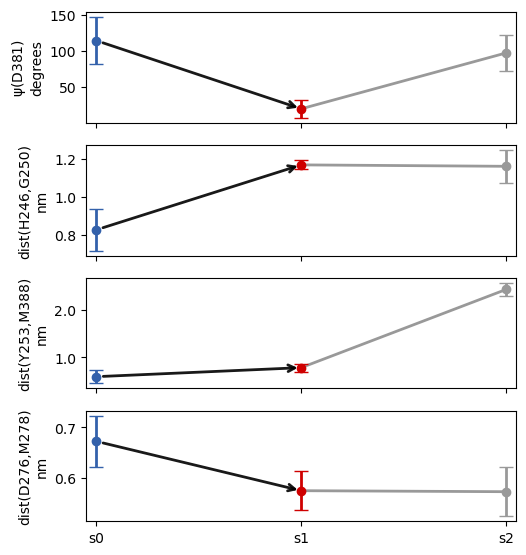

In [5]:
features_labels = ['Psi D381', 'Dist H246-G250', 'Dist Y253-M388', 'Dist D276-M278']
y_labels = ['$\mathrm{\\psi}$(D381)\ndegrees', 'dist(H246,G250)\nnm', 'dist(Y253,M388)\nnm', 'dist(D276,M278)\nnm']
x_labels = ['s0', 's1', 's2']

n_features = len(features_labels)
cm_to_inch = lambda cm: cm / 2.54
fig, axes = plt.subplots(n_features, 1, figsize=(cm_to_inch(4.7)*3, cm_to_inch(5.6)*3), sharex=True)

for i in range(n_features):
    xs = np.arange(len(transition))
    y_means = np.array([np.mean(t[:, i]) for t in transition])
    y_errs = np.array([np.std(t[:, i]) for t in transition])

    # locate bottleneck index
    try:
        b_idx = x_labels.index('s0')
    except ValueError:
        b_idx = 0

    # draw gray connecting lines except the bottleneck->next segment
    for k in range(len(xs) - 1):
        if k == b_idx:
            continue
        axes[i].plot(xs[k:k+2], y_means[k:k+2], color='0.6', lw=2, alpha=1, zorder=1)

    # draw arrow from bottleneck to next (black)
    if b_idx + 1 < len(xs):
        axes[i].annotate('',
                         xy=(xs[b_idx + 1], y_means[b_idx + 1]),
                         xytext=(xs[b_idx], y_means[b_idx]),
                         arrowprops=dict(arrowstyle='->', color='k', lw=2, shrinkA=5, shrinkB=2.5, mutation_scale=12, alpha=0.9),
                         zorder=2)

    # plot points + error bars
    mask = np.ones_like(xs, dtype=bool)
    mask[b_idx] = False
    if b_idx + 1 < len(xs):
        mask[b_idx + 1] = False
    if mask.any():
        axes[i].errorbar(xs[mask], y_means[mask], yerr=y_errs[mask], fmt='o', color='0.6', ecolor='0.6',
                         capsize=5, alpha=1, lw=2, label=features_labels[i], zorder=3)
    # bottleneck
    axes[i].errorbar(xs[b_idx], y_means[b_idx], yerr=y_errs[b_idx], fmt='o', color=(0.2, 0.38, 0.67), ecolor=(0.2, 0.38, 0.67),
                     capsize=5, alpha=1, lw=2, zorder=4)
    # next
    if b_idx + 1 < len(xs):
        axes[i].errorbar(xs[b_idx + 1], y_means[b_idx + 1], yerr=y_errs[b_idx + 1], fmt='o', color=(0.81, 0, 0), ecolor=(0.81, 0, 0),
                         capsize=5, alpha=1, lw=2, zorder=4)

    # axes[i].legend(loc='upper right')
    axes[i].set_ylabel(y_labels[i])
    # No decimals for angle panels, one decimal for distances
    fmt = '%.0f' if 'degrees' in y_labels[i] else '%.1f'
    axes[i].yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter(fmt))
    axes[i].set_xlim([0-0.05, len(transition)-1+0.05])
    axes[i].set_xticks(np.arange(len(transition)))
    axes[i].tick_params(labelbottom=False)
    
axes[-1].set_xticklabels(x_labels)
axes[-1].tick_params(labelbottom=True)

plt.savefig('feature_transition_abl.pdf', dpi=400, bbox_inches='tight')
plt.show()

Plot a/b/l/chi assignment of transition states.

In [ ]:
dihedrals = [dbdihed_featuriser(bn, protein='abl'), 
             dbdihed_featuriser(pbn, protein='abl'), 
             dbdihed_featuriser(s2, protein='abl')]

In [ ]:
_, _, _, _, codes = assign_ramachandran_codes(dihedrals)

codes = list(codes)

state_labels = ['bottleneck', 's1', 's2']
fig, axes = plt.subplots(1, len(codes), figsize=(4 * len(codes), 4))
axes = np.atleast_1d(axes)

for idx, (ax, state_codes) in enumerate(zip(axes, codes)):
    labels, counts = np.unique(state_codes, return_counts=True)
    total = counts.sum()

    if total == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')
        continue

    def format_autopct(pct, total=total):
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count})" if count > 0 else ''

    ax.pie(counts, labels=labels, autopct=format_autopct, startangle=90, counterclock=False)
    ax.set_title(f"{state_labels[idx]}")
    ax.set_aspect('equal')

fig.suptitle('ABL_Ramachandran_Code_Populations_per_State', y=1.02)
plt.savefig('abl_ramachandran_code_populations_per_state.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

### EGFR

---

In [6]:
def get_egfr_features(traj):
    psi_indices, psi_angles = md.compute_psi(traj)
    phi_indices, phi_angles = md.compute_phi(traj)
    chi1_indices, chi1_angles = md.compute_chi1(traj)

    phi_ASP855 = phi_angles[:,np.where(phi_indices==[1199, 1204, 1205, 1206])[0][0]]/np.pi*180 # DFG
    # chi1_ASP855 = chi1_angles[:,np.where(chi1_indices==[1204, 1205, 1208, 1209])[0][0]] # DFG
    dist_LEU838_ALA859 = md.compute_distances(traj, [[1073, 1236]],) # A-loop
    dist_GLU865_LYS875 = md.compute_distances(traj, [[1275, 1355]],) # A-loop
    dist_GLU749_ASN756 = md.compute_distances(traj, [[363, 411]],) # C-helix
    # dist_GLY735_LYS737 = md.compute_distances(traj, [[253, 266]],) # beta-turn (?)

    features = np.vstack([phi_ASP855, dist_LEU838_ALA859[:,0], dist_GLU865_LYS875[:,0], dist_GLU749_ASN756[:,0]]).T
    return features

In [7]:
s0 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/egfr-pathway-structures-files/pathway_state_index_0_1000_samples.pdb')
s1 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/egfr-pathway-structures-files/pathway_state_index_1_1000_samples.pdb')
s2 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/egfr-pathway-structures-files/pathway_state_index_2_1000_samples.pdb')
bn = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/egfr-pathway-structures-files/bottleneck_1000_samples.pdb')
s4 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/egfr-pathway-structures-files/post_bottleneck_1000_samples.pdb')
s5 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/egfr-pathway-structures-files/pathway_state_index_5_1000_samples.pdb')
s6 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/egfr-pathway-structures-files/pathway_state_index_6_1000_samples.pdb')
s7 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/egfr-pathway-structures-files/pathway_state_index_7_1000_samples.pdb')
s8 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/egfr-pathway-structures-files/pathway_state_index_8_1000_samples.pdb')

In [8]:
transition = [get_egfr_features(s0),
              get_egfr_features(s1),
              get_egfr_features(s2),
              get_egfr_features(bn),
              get_egfr_features(s4),
              get_egfr_features(s5),
              get_egfr_features(s6),
              get_egfr_features(s7),
              get_egfr_features(s8)]

egfr_state_trajs = [
    ('s0', s0),
    ('s1', s1),
    ('s2', s2),
    ('s3', bn),
    ('s4', s4),
    ('s5', s5),
    ('s6', s6),
    ('s7', s7),
    ('s8', s8),
]
egfr_state_labels = [label for label, _ in egfr_state_trajs]


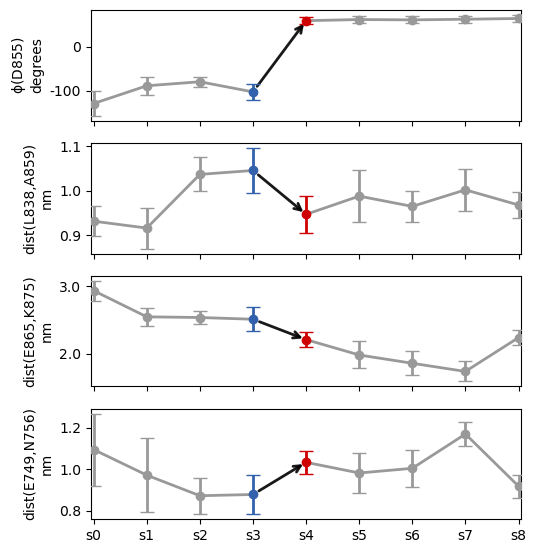

In [9]:
features_labels = ['Phi D855', 'Dist L838-A859', 'Dist E865-K875', 'Dist E749-N756']
y_labels = ['$\mathrm{\\phi}$(D855)\ndegrees', 'dist(L838,A859)\nnm', 'dist(E865,K875)\nnm', 'dist(E749,N756)\nnm']
x_labels = [label for label, _ in egfr_state_trajs]

n_features = len(features_labels)
cm_to_inch = lambda cm: cm / 2.54
fig, axes = plt.subplots(n_features, 1, figsize=(cm_to_inch(4.7)*3, cm_to_inch(5.6)*3), sharex=True)

for i in range(n_features):
    xs = np.arange(len(transition))
    y_means = np.array([np.mean(t[:, i]) for t in transition])
    y_errs = np.array([np.std(t[:, i]) for t in transition])

    # locate bottleneck index
    try:
        b_idx = x_labels.index('s3')
    except ValueError:
        b_idx = 0

    # draw gray connecting lines except the bottleneck->next segment
    for k in range(len(xs) - 1):
        if k == b_idx:
            continue
        axes[i].plot(xs[k:k+2], y_means[k:k+2], color='0.6', lw=2, alpha=1, zorder=1)

    # draw arrow from bottleneck to next (black)
    if b_idx + 1 < len(xs):
        axes[i].annotate('',
                         xy=(xs[b_idx + 1], y_means[b_idx + 1]),
                         xytext=(xs[b_idx], y_means[b_idx]),
                         arrowprops=dict(arrowstyle='->', color='k', lw=2, shrinkA=5, shrinkB=2.5, mutation_scale=12, alpha=0.9),
                         zorder=2)

    # plot points + error bars
    mask = np.ones_like(xs, dtype=bool)
    mask[b_idx] = False
    if b_idx + 1 < len(xs):
        mask[b_idx + 1] = False
    if mask.any():
        axes[i].errorbar(xs[mask], y_means[mask], yerr=y_errs[mask], fmt='o', color='0.6', ecolor='0.6',
                         capsize=5, alpha=1, lw=2, label=features_labels[i], zorder=3)
    # bottleneck
    axes[i].errorbar(xs[b_idx], y_means[b_idx], yerr=y_errs[b_idx], fmt='o', color=(0.2, 0.38, 0.67), ecolor=(0.2, 0.38, 0.67),
                     capsize=5, alpha=1, lw=2, zorder=4)
    # next
    if b_idx + 1 < len(xs):
        axes[i].errorbar(xs[b_idx + 1], y_means[b_idx + 1], yerr=y_errs[b_idx + 1], fmt='o', color=(0.81, 0, 0), ecolor=(0.81, 0, 0),
                         capsize=5, alpha=1, lw=2, zorder=4)

    # axes[i].legend(loc='upper right')
    axes[i].set_ylabel(y_labels[i])
    # No decimals for angle panels, one decimal for distances
    fmt = '%.0f' if 'degrees' in y_labels[i] else '%.1f'
    axes[i].yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter(fmt))
    axes[i].set_xlim([0-0.05, len(transition)-1+0.05]) 
    axes[i].set_xticks(np.arange(len(transition)))
    axes[i].tick_params(labelbottom=False)
    
axes[-1].set_xticklabels(x_labels)
axes[-1].tick_params(labelbottom=True)

plt.savefig('feature_transition_egfr.pdf', dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
egfr_dihedrals = [dbdihed_featuriser(traj, protein='egfr') for _, traj in egfr_state_trajs]
_, _, _, _, codes = assign_ramachandran_codes(egfr_dihedrals)

codes = list(codes)

state_labels = egfr_state_labels
fig, axes = plt.subplots(1, len(codes), figsize=(4 * len(codes), 4))
axes = np.atleast_1d(axes)

for idx, (ax, state_codes) in enumerate(zip(axes, codes)):
    labels, counts = np.unique(state_codes, return_counts=True)
    total = counts.sum()

    if total == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')
        continue

    def format_autopct(pct, total=total):
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count})" if count > 0 else ''

    ax.pie(counts, labels=labels, autopct=format_autopct, startangle=90, counterclock=False)
    ax.set_title(f"{state_labels[idx]}")
    ax.set_aspect('equal')

fig.suptitle('EGFR_Ramachandran_Code_Populations_per_State', y=1.02)
plt.savefig('egfr_ramachandran_code_populations_per_state.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

### MET

---

In [7]:
def get_met_features(traj):
    psi_indices, psi_angles = md.compute_psi(traj)
    phi_indices, phi_angles = md.compute_phi(traj)
    chi1_indices, chi1_angles = md.compute_chi1(traj)

    phi_ARG161 = phi_angles[:,np.where(phi_indices==[1234, 1237, 1238, 1239])[0][0]]/np.pi*180    # A-loop
    # chi1_PHE134 = chi1_angles[:,np.where(chi1_indices==[1023, 1024, 1027, 1028])[0][0]]/np.pi*180 # A-loop
    dist_MET163_GLU167 = md.compute_distances(traj, [[1257, 1294]],) # A-loop
    dist_HIS2_ILE49 = md.compute_distances(traj, [[1, 362]],) # C-helix
    dist_ILE18_PHE23 = md.compute_distances(traj, [[124, 161]],) # G-loop

    features = np.array([phi_ARG161, dist_MET163_GLU167[:,0], dist_HIS2_ILE49[:,0], dist_ILE18_PHE23[:,0]]).T
    return features

In [30]:
def get_met_features(traj):
    psi_indices, psi_angles = md.compute_psi(traj)
    phi_indices, phi_angles = md.compute_phi(traj)
    chi1_indices, chi1_angles = md.compute_chi1(traj)

    chi_ASP155 = chi1_angles[:,np.where(chi1_indices==[1201, 1202, 1205, 1206])[0][0]]/np.pi*180    # DFG-D / DFG-out -> DFG-inter
    # psi_LYS165 = psi_angles[:,np.where(psi_indices==[1284, 1285, 1286, 1293])[0][0]]/np.pi*180    # A-loop / helix formation
    phi_ARG160 = phi_angles[:,np.where(phi_indices==[1234, 1237, 1238, 1239])[0][0]]/np.pi*180
    dist_VAL3_ARG19  = md.compute_distances(traj, [[18, 136]],) # G-loop / moves towards pocket
    dist_ILE51_PHE57 = md.compute_distances(traj, [[385, 428]],) # C-helix / bending to pack with helical content
    features = np.array([chi_ASP155, phi_ARG160, dist_VAL3_ARG19[:,0], dist_ILE51_PHE57[:,0]]).T
    return features

In [5]:
s0 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/processed_0/merged.pdb')
s1 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/processed_1/merged.pdb')
s2 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/processed_2/merged.pdb')
bn = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/model_532_pathway-7-to-6_bottleneck_processed/merged.pdb')
s4 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/model_532_pathway-7-to-6_post-bottleneck_processed/merged.pdb')
s5 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/processed_5/merged.pdb')
s6 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/processed_6/merged.pdb')
s7 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/processed_7/merged.pdb')
s8 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/processed_8/merged.pdb')
s9 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/processed_9/merged.pdb')
s10 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/processed_10/merged.pdb')
s11 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/processed_11/merged.pdb')
s12 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/processed_12/merged.pdb')
s13 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/processed_13/merged.pdb')
s14 = md.load('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/analysis/met_samples/pathway_7-to-6_structures/processed_14/merged.pdb')

In [31]:
transition = [get_met_features(s0),
              get_met_features(s1),
              get_met_features(s2),
              get_met_features(bn),
              get_met_features(s4),
              get_met_features(s5),
              get_met_features(s6),
              get_met_features(s7),
              get_met_features(s8),
              get_met_features(s9),
              get_met_features(s10),
              get_met_features(s11),
              get_met_features(s12),
              get_met_features(s13),
              get_met_features(s14),
             ]

met_state_trajs = [
    ('s0', s0),
    ('s1', s1),
    ('s2', s2),
    ('s3', bn),
    ('s4', s4),
    ('s5', s5),
    ('s6', s6),
    ('s7', s7),
    ('s8', s8),
    ('s9', s9),
    ('s10', s10),
    ('s11', s11),
    ('s12', s12),
    ('s13', s13),
    ('s14', s14),
]

In [32]:
np.mean(get_met_features(s2), axis=0)

array([ -47.411983  , -147.38472   ,    2.3765688 ,    0.97954667],
      dtype=float32)

In [33]:
np.mean(get_met_features(bn), axis=0)

array([ -45.21304   , -149.52716   ,    2.3747542 ,    0.95685375],
      dtype=float32)

In [34]:
np.mean(get_met_features(s4), axis=0)

array([ 64.68701  , -60.52915  ,   2.5276442,   0.7806712], dtype=float32)

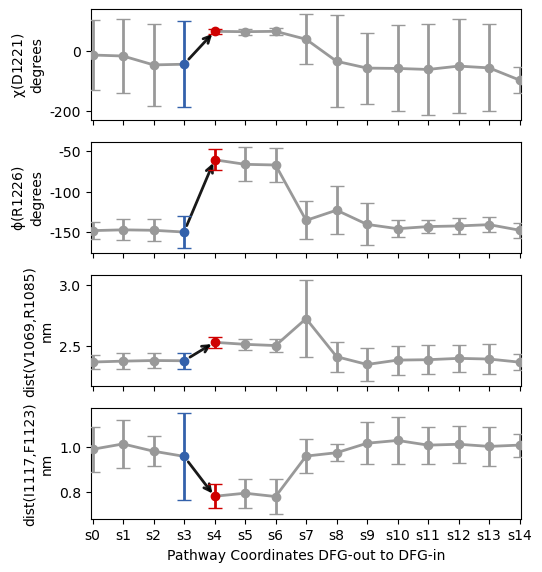

In [38]:
# Add 1066 to residue numbers above to convert to PDB numbering
features_labels = ['Chi D155', 'Phi R160', 'Dist V3-R19', 'Dist I51-F57']
y_labels = ['$\mathrm{\\chi}$(D1221)\ndegrees', '$\mathrm{\\phi}$(R1226)\ndegrees', 'dist(V1069,R1085)\nnm', 'dist(I1117,F1123)\nnm']
# y_labels = ['Phi R161 (°)', 'Chi1 F134 (°)', 'Dist. M163–E167 (nm)', 'Dist. H2-I49 (nm)', 'Dist. I18-F23 (nm)']
x_labels = [label for label, _ in met_state_trajs]

n_features = len(features_labels)
cm_to_inch = lambda cm: cm / 2.54
fig, axes = plt.subplots(n_features, 1, figsize=(cm_to_inch(4.7)*3, cm_to_inch(5.6)*3), sharex=True)

for i in range(n_features):
    xs = np.arange(len(transition))
    y_means = np.array([np.mean(t[:, i]) for t in transition])
    y_errs = np.array([np.std(t[:, i]) for t in transition])

    # locate bottleneck index
    try:
        b_idx = x_labels.index('s3')
    except ValueError:
        b_idx = 0

    # draw gray connecting lines except the bottleneck->next segment
    for k in range(len(xs) - 1):
        if k == b_idx:
            continue
        axes[i].plot(xs[k:k+2], y_means[k:k+2], color='0.6', lw=2, alpha=1, zorder=1)

    # draw arrow from bottleneck to next (black)
    if b_idx + 1 < len(xs):
        axes[i].annotate('',
                         xy=(xs[b_idx + 1], y_means[b_idx + 1]),
                         xytext=(xs[b_idx], y_means[b_idx]),
                         arrowprops=dict(arrowstyle='->', color='k', lw=2, shrinkA=5, shrinkB=2.5, mutation_scale=12, alpha=0.9),
                         zorder=2)

    # plot points + error bars
    mask = np.ones_like(xs, dtype=bool)
    mask[b_idx] = False
    if b_idx + 1 < len(xs):
        mask[b_idx + 1] = False
    if mask.any():
        axes[i].errorbar(xs[mask], y_means[mask], yerr=y_errs[mask], fmt='o', color='0.6', ecolor='0.6',
                         capsize=5, alpha=1, lw=2, label=features_labels[i], zorder=3)
    # bottleneck
    axes[i].errorbar(xs[b_idx], y_means[b_idx], yerr=y_errs[b_idx], fmt='o', color=(0.2, 0.38, 0.67), ecolor=(0.2, 0.38, 0.67),
                     capsize=5, alpha=1, lw=2, zorder=4)
    # next
    if b_idx + 1 < len(xs):
        axes[i].errorbar(xs[b_idx + 1], y_means[b_idx + 1], yerr=y_errs[b_idx + 1], fmt='o', color=(0.81, 0, 0), ecolor=(0.81, 0, 0),
                         capsize=5, alpha=1, lw=2, zorder=4)

    # axes[i].legend(loc='upper right')
    axes[i].set_ylabel(y_labels[i])
    # No decimals for angle panels, one decimal for distances
    fmt = '%.0f' if 'degrees' in y_labels[i] else '%.1f'
    axes[i].yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter(fmt))
    axes[i].set_xlim([0-0.05, len(transition)-1+0.05])
    axes[i].set_xticks(np.arange(len(transition)))
    axes[i].tick_params(labelbottom=False)
    
axes[-1].set_xticklabels(x_labels)
axes[-1].tick_params(labelbottom=True)
axes[-1].set_xlabel("Pathway Coordinates DFG-out to DFG-in")
plt.savefig('feature_transition_met.pdf', dpi=400, bbox_inches='tight')
plt.show()